In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
import numpy as np
import yaml
import pickle
from itertools import product, cycle
import os, sys
from tqdm.notebook import tqdm
from scipy import stats

from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[1]))

In [2]:
# load simulation results

simulation_path = "../output/sensitivity_results06_03_2026.pkl"

with open(simulation_path, 'rb') as input_file:
    simulation_results = pickle.load(input_file)

In [3]:
list(simulation_results.keys())[0]

(33, 0.75, 0.75, 0.0, 0, 3, 5, 0.3)

(33,
  0.75,
  0.5,
  0.0,
  0,
  0,
  5,
  0.3)

key of a result, in order:
- dataset_id
- prop
- mf_prop
- mnar_prop
- seed (for this analysis always 0 as first run is used)
- proj
- knn
- co_threshold

In [4]:
# Load simulation configuration

with open("../config/simulation_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# conf is a tuple (dataset_id,props,mf_proportions,mnar_proportions, seed)

simulations_results = {}
configs = list(product(
    cfg['dataset_ids'],
    cfg['md_param_grid']['props'],
    cfg['md_param_grid']['mf_proportions'],
    cfg['md_param_grid']['mnar_proportions'],
    range(cfg['n_runs'])
))


In [5]:

# get from sensitivity analysis script 

# from script 4_sensitivity_analysis 
consensuns_thresholds = [0.3,0.5,0.7]
knn_numbers = [5,20,40] 
projections = [3]

# grid of the tested hyperparameters
sensitivity_conf = product(knn_numbers, consensuns_thresholds)

TEST_DATASETS = [15,17,33,45,174,544]
filtered_configs = [cf for cf in configs if (cf[0] in TEST_DATASETS) and ((cf[4] == 0) or (cf[4] == 1)) and (cf[2] >= .75)]


In [6]:
# PROJECTION RESULTS 

# modify for selected projections
p = 3

# take ari for simulation for all hyperparameters configurations 

formatted_res = {}
formatted_res = {
        'ami': {d: {} for d in TEST_DATASETS},
        'ari': {d: {} for d in TEST_DATASETS}
    }

for dataset in TEST_DATASETS:
    for knn, co_hat in product(knn_numbers, consensuns_thresholds):
        formatted_res['ari'][dataset][(knn, co_hat)] = []
        formatted_res['ami'][dataset][(knn, co_hat)] = []

# iterate across all imputed datasets
for config in filtered_configs:
    
    d_id = config[0]
    prop = config[1]
    mf_prop = config[2]
    mnar_prop = config[3]
    seed = config[4]

    

    for knn, co_hat in product(knn_numbers, consensuns_thresholds):
        
        ari_res = simulation_results[config+(p, knn, co_hat)]['external_metrics']['ari']
        ami_res = simulation_results[config+(p, knn, co_hat)]['external_metrics']['ami']

        formatted_res['ari'][d_id][(knn, co_hat)].append(ari_res)
        formatted_res['ami'][d_id][(knn, co_hat)].append(ami_res)


formatted_res_aggregates = {}
formatted_res_aggregates['mean'] = {}
formatted_res_aggregates['std'] = {}

for agg,metric in product(['mean','std'],['ari','ami']):
    
    formatted_res_aggregates['mean'] = {
        'ami': {d: {} for d in TEST_DATASETS},
        'ari': {d: {} for d in TEST_DATASETS}
    }
    formatted_res_aggregates['std'] = {
        'ami': {d: {} for d in TEST_DATASETS},
        'ari': {d: {} for d in TEST_DATASETS}
    }

    for dataset in TEST_DATASETS:
        for knn, co_hat in product(knn_numbers, consensuns_thresholds):
            for metric in ['ami','ari']:
                formatted_res_aggregates['mean'][metric][dataset][(knn, co_hat)] = np.mean(formatted_res[metric][dataset][(knn, co_hat)])
                formatted_res_aggregates['std'][metric][dataset][(knn, co_hat)] = np.std(formatted_res[metric][dataset][(knn, co_hat)])
            

Bidimensional data

In [7]:
len(formatted_res['ami'][15][(5, 0.3)])

12

In [22]:
for metric in ['ari','ami']:
    for dataset in formatted_res['ami'].keys():
        samples = []
        for hyperpam_conf in formatted_res['ami'][15].keys():
            samples.append(formatted_res[metric][dataset][hyperpam_conf])
        stat,pval = stats.kruskal(*samples)
        if pval*6 < 0.05:
            print(f"matric: {metric} dataset: {dataset} pvalue: {pval}*")
        else:
            print(f"matric: {metric} dataset: {dataset} pvalue: {pval}")

matric: ari dataset: 15 pvalue: 0.035225911232112925
matric: ari dataset: 17 pvalue: 0.0004202175948638612*
matric: ari dataset: 33 pvalue: 0.03174768848745386
matric: ari dataset: 45 pvalue: 0.38364341968078125
matric: ari dataset: 174 pvalue: 3.28126277905479e-08*
matric: ari dataset: 544 pvalue: 0.023839447323658006
matric: ami dataset: 15 pvalue: 0.13830524870253444
matric: ami dataset: 17 pvalue: 0.19665971502399052
matric: ami dataset: 33 pvalue: 0.0006634332423428602*
matric: ami dataset: 45 pvalue: 0.0007384543111059546*
matric: ami dataset: 174 pvalue: 0.2523985536426317
matric: ami dataset: 544 pvalue: 0.09498374120999577


KruskalResult(statistic=np.float64(13.526134263229135), pvalue=np.float64(0.09498374120999577))

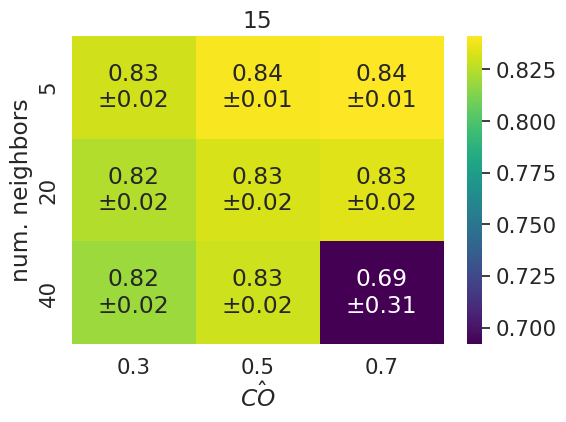

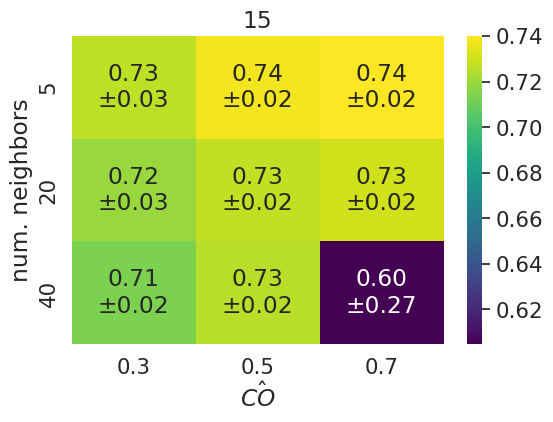

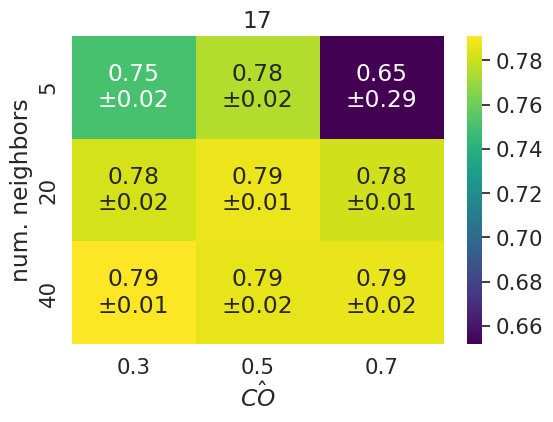

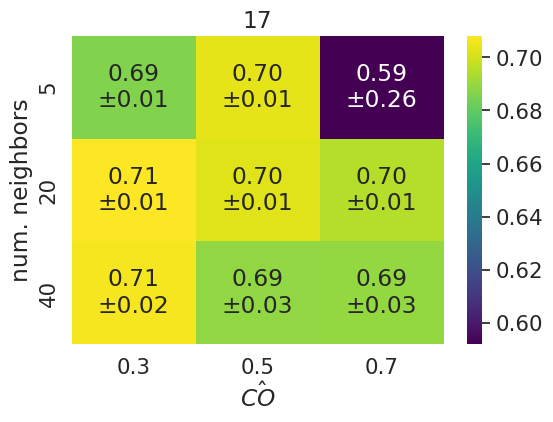

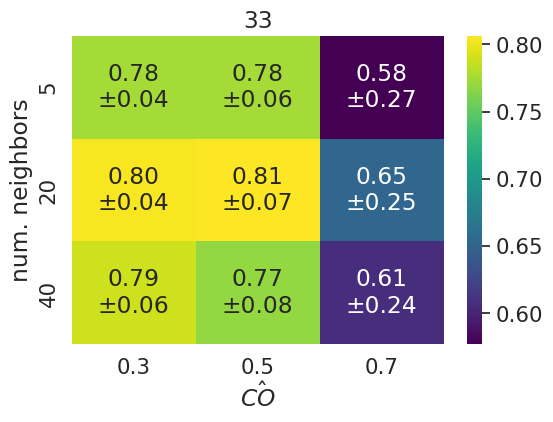

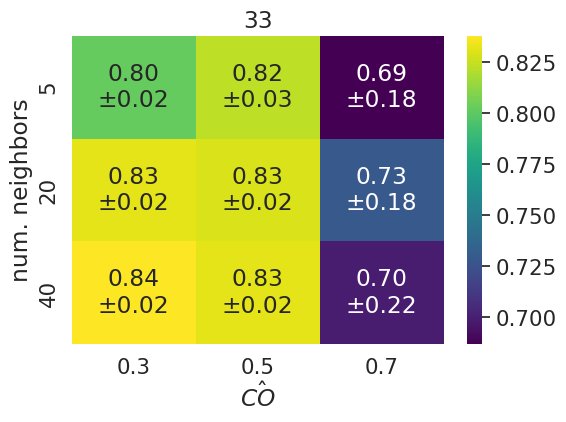

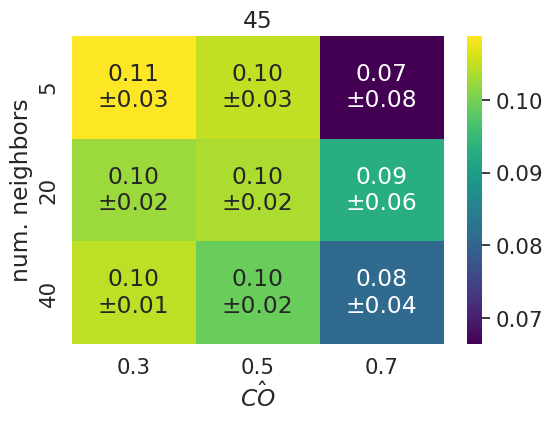

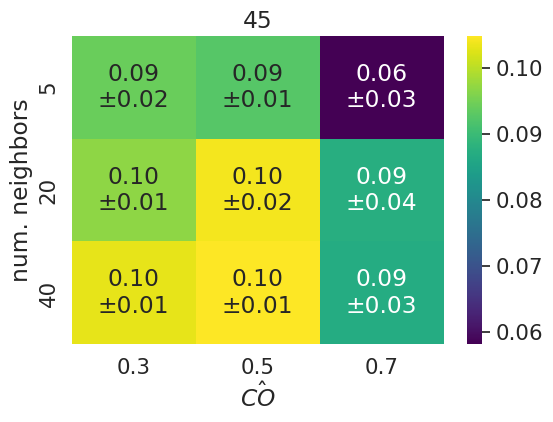

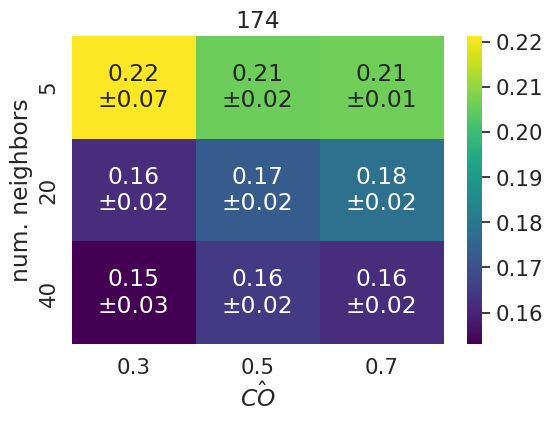

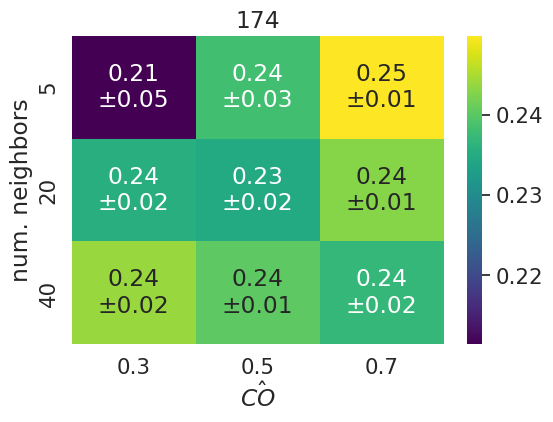

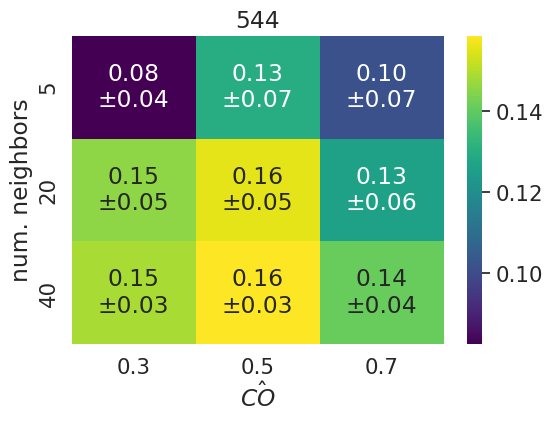

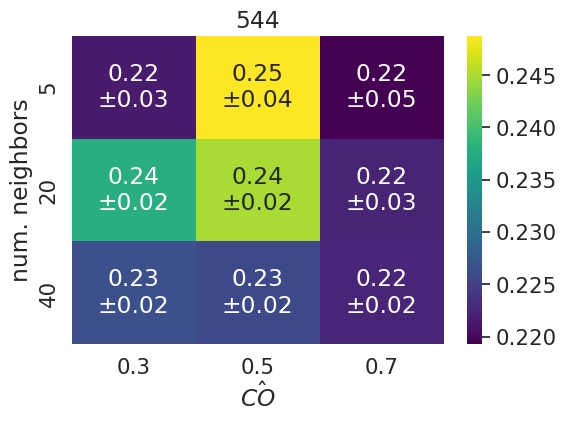

In [11]:

dataset_id = TEST_DATASETS[0]

for dataset_id,metric in product(TEST_DATASETS,['ari','ami']):


    mean_data = formatted_res_aggregates['mean'][metric][dataset_id]
    std_data = formatted_res_aggregates['std'][metric][dataset_id]

    # Convert to DataFrame
    df_mean = pd.DataFrame(
        [(k[0], k[1], v) for k, v in mean_data.items()],
        columns=["x", "y", "value"]
    )
    df_std = pd.DataFrame(
        [(k[0], k[1], v) for k, v in std_data.items()],
        columns=["x", "y", "value"]
    )

    heatmap_mean = df_mean.pivot(index="x", columns="y", values="value")
    heatmap_std = df_std.pivot(index="x", columns="y", values="value")

    annot = heatmap_mean.copy().astype(str)

    for i in heatmap_mean.index:
        for j in heatmap_mean.columns:
            m = heatmap_mean.loc[i, j]
            s = heatmap_std.loc[i, j]
            annot.loc[i, j] = f"{m:.2f}\n±{s:.2f}"


    # Plot
    plt.figure(figsize=(6,4))
    sns.set(font_scale=1.4)
    sns.heatmap(
        heatmap_mean,
        annot=annot,
        fmt="",
        cmap="viridis"
    )

    plt.xlabel(r"$\hat{CO}$")
    plt.ylabel("num. neighbors")
    plt.title(str(dataset_id))
    plt.savefig(f"../output/figures/sensitivity/heatmap_{dataset_id}_{metric}.pdf", bbox_inches="tight")
    plt.show()